<a href="https://colab.research.google.com/github/harishkumarsg/Fake-News-Detection---NLP/blob/main/Fake_News_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
print(torch.cuda.get_device_name(0))

Tesla T4


In [2]:
# ============================================================
# STEP 0: UPLOAD DATASET FILES TO COLAB
# Run this cell first, then upload Fake.csv and True.csv
# ============================================================
from google.colab import files

print("Please upload Fake.csv and True.csv from your local machine")
uploaded = files.upload()  # A file picker will appear — select both CSV files
print("\nFiles uploaded:", list(uploaded.keys()))

Please upload Fake.csv and True.csv from your local machine


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv

Files uploaded: ['Fake.csv', 'True.csv']


In [3]:
# ============================================================
# SECTION 1: INSTALL LIBRARIES
# These are needed for NLP processing, ML models, and BERT
# ============================================================

# Install HuggingFace Transformers and PyTorch utilities
!pip install transformers==4.40.0 -q
!pip install torch -q
!pip install wordcloud -q

# Download NLTK resources needed for text preprocessing
import nltk
nltk.download('stopwords')       # Common English stopwords list
nltk.download('wordnet')         # Lexical database for lemmatization
nltk.download('averaged_perceptron_tagger')  # POS tagger
nltk.download('punkt')           # Sentence tokenizer

print("✅ All libraries installed and NLTK data downloaded!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 100.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ All libraries installed and NLTK data downloaded!


In [4]:
# ============================================================
# SECTION 2: IMPORT ALL REQUIRED LIBRARIES
# ============================================================

# --- Data Handling ---
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# --- NLP / Text Preprocessing ---
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# --- Feature Engineering ---
from sklearn.feature_extraction.text import TfidfVectorizer

# --- Machine Learning Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

# --- Evaluation Metrics ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# --- Deep Learning (BERT) ---
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    AdamW,
    get_linear_schedule_with_warmup
)

# --- Check GPU availability ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  No GPU found. Go to Runtime > Change Runtime Type > GPU for faster BERT training.")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("\n✅ All libraries imported successfully!")

✅ Using device: cuda
   GPU: Tesla T4

✅ All libraries imported successfully!


In [5]:
# ============================================================
# SECTION 3: LOAD AND COMBINE THE DATASET
# ============================================================

# Load the two CSV files separately
fake_df = pd.read_csv('Fake.csv')
real_df = pd.read_csv('True.csv')

# Add label column: 0 = Fake, 1 = Real
fake_df['label'] = 0
real_df['label'] = 1

print(f"Fake news articles: {len(fake_df):,}")
print(f"Real news articles: {len(real_df):,}")

# Combine both datasets into one DataFrame
df = pd.concat([fake_df, real_df], ignore_index=True)

# Shuffle the dataset to mix fake and real
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nCombined dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Preview the first few rows
df.head()

Fake news articles: 23,481
Real news articles: 21,417

Combined dataset shape: (44898, 5)
Columns: ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [6]:
# ============================================================
# BASIC DATASET EXPLORATION
# ============================================================

print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("CLASS DISTRIBUTION")
print("=" * 50)
label_map = {0: 'Fake', 1: 'Real'}
print(df['label'].value_counts().rename(index=label_map))

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB

MISSING VALUES
title      0
text       0
subject    0
date       0
label      0
dtype: int64

CLASS DISTRIBUTION
label
Fake    23481
Real    21417
Name: count, dtype: int64


In [7]:
# ============================================================
# SECTION 4: TEXT PREPROCESSING PIPELINE
# Steps: combine fields → lowercase → remove noise →
#        tokenize → remove stopwords → lemmatize
# ============================================================

# Initialize tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full NLP preprocessing pipeline:
    1. Convert to lowercase
    2. Remove URLs, HTML tags, punctuation, and numbers
    3. Tokenize into individual words
    4. Remove English stopwords
    5. Lemmatize tokens to their base form
    """
    # Step 1: Lowercase
    text = str(text).lower()

    # Step 2: Remove URLs (e.g., http://...)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Step 3: Remove HTML tags (e.g., <br>, <p>)
    text = re.sub(r'<.*?>', '', text)

    # Step 4: Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Step 5: Remove numbers
    text = re.sub(r'\d+', '', text)

    # Step 6: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 7: Tokenize — split into words
    tokens = text.split()

    # Step 8: Remove stopwords and short tokens (<= 2 chars)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # Step 9: Lemmatize — e.g., 'running' → 'run'
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

# Combine title and text for richer features
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

print("Preprocessing text... (this may take 1-2 minutes)")
df['clean_text'] = df['content'].apply(preprocess_text)

print("\n✅ Preprocessing complete!")
print("\nSample BEFORE preprocessing:")
print(df['content'].iloc[0][:300])
print("\nSample AFTER preprocessing:")
print(df['clean_text'].iloc[0][:300])

Preprocessing text... (this may take 1-2 minutes)

✅ Preprocessing complete!

Sample BEFORE preprocessing:
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements 

Sample AFTER preprocessing:
ben stein call circuit court committed ‘coup d’état’ constitution century wire say ben stein reputable professor pepperdine university also hollywood fame appearing show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump execu


In [8]:
# ============================================================
# ADD TEXT LENGTH FEATURES (useful for EDA and ML)
# ============================================================

# Word count in raw content
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))

# Character count
df['char_count'] = df['content'].apply(lambda x: len(str(x)))

print("Text length statistics by label:")
print(df.groupby('label')[['word_count', 'char_count']].describe().round(1))

Text length statistics by label:
      word_count                                                 char_count  \
           count   mean    std  min    25%    50%    75%     max      count   
label                                                                         
0        23481.0  437.9  408.6  2.0  254.0  378.0  521.0  8148.0    23481.0   
1        21417.0  395.6  273.9  4.0  159.0  369.0  534.0  5181.0    21417.0   

                                                              
         mean     std   min     25%     50%     75%      max  
label                                                         
0      2642.6  2533.7  31.0  1530.0  2259.0  3126.0  51893.0  
1      2448.9  1684.4  32.0   980.0  2286.0  3301.0  29849.0  


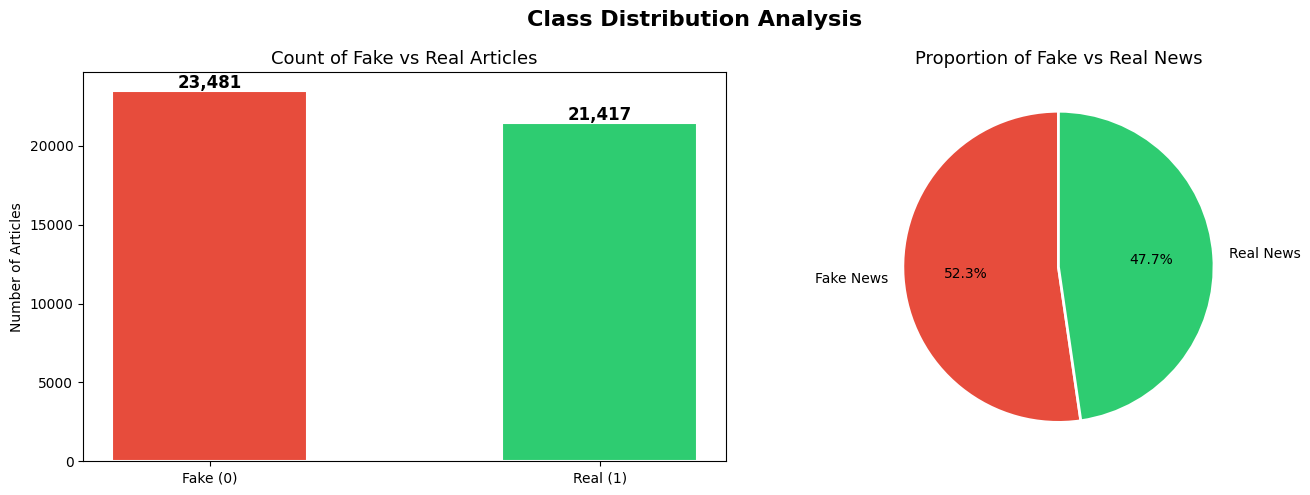

✅ Class distribution plot saved.


In [9]:
# ============================================================
# SECTION 5A: CLASS DISTRIBUTION PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution Analysis', fontsize=16, fontweight='bold')

# --- Bar Chart ---
label_counts = df['label'].value_counts()
colors = ['#E74C3C', '#2ECC71']   # Red for Fake, Green for Real
bars = axes[0].bar(['Fake (0)', 'Real (1)'], label_counts.values,
                   color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Count of Fake vs Real Articles', fontsize=13)
axes[0].set_ylabel('Number of Articles')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')

# --- Pie Chart ---
axes[1].pie(label_counts.values,
            labels=['Fake News', 'Real News'],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion of Fake vs Real News', fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Class distribution plot saved.")

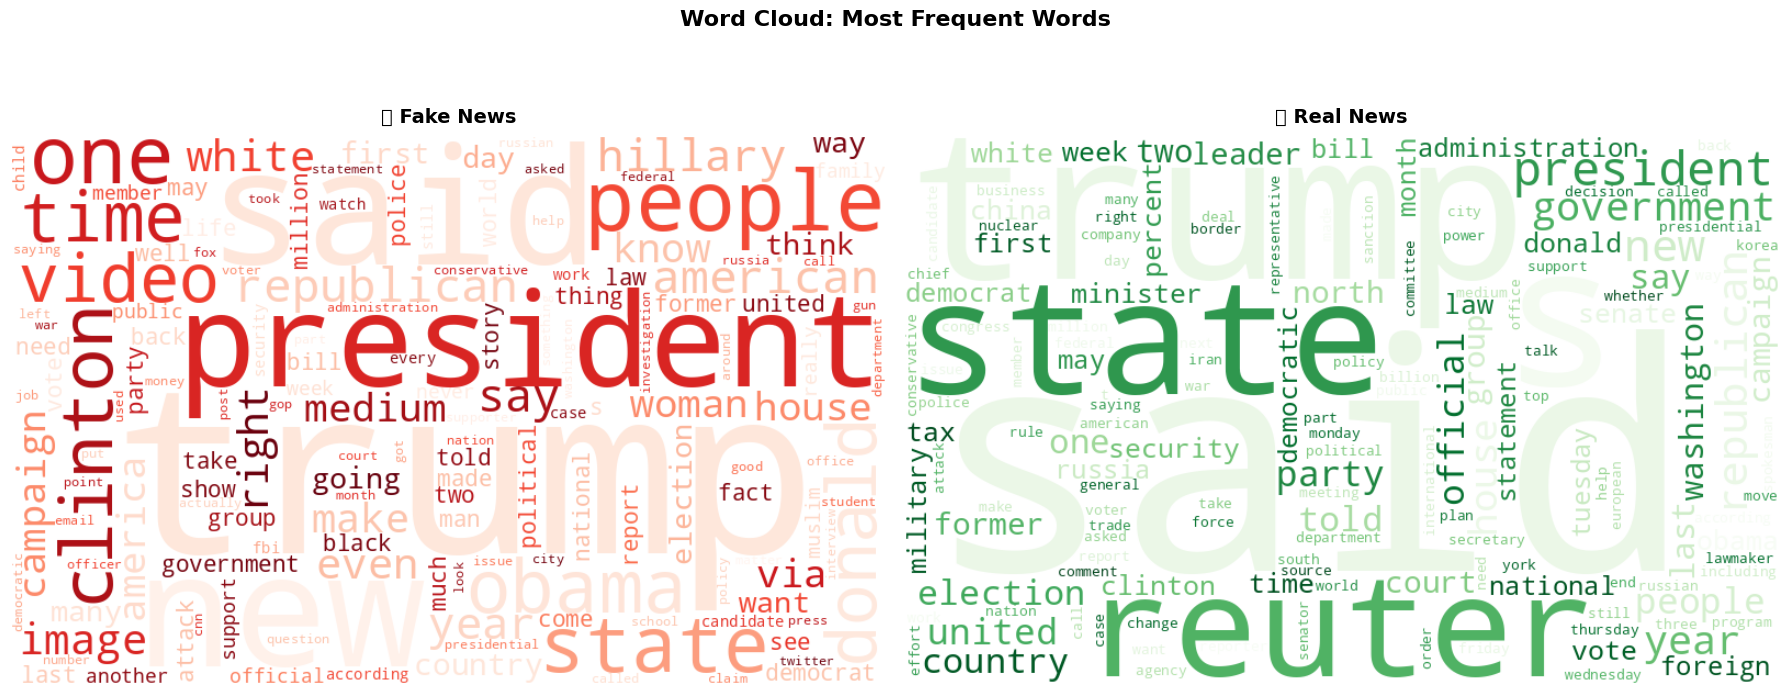

✅ Word clouds saved.


In [10]:
# ============================================================
# SECTION 5B: WORD CLOUD VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Word Cloud: Most Frequent Words', fontsize=16, fontweight='bold')

for idx, (label, title, colormap) in enumerate([
    (0, '🔴 Fake News', 'Reds'),
    (1, '🟢 Real News', 'Greens')
]):
    # Get all cleaned text for this class
    text_data = ' '.join(df[df['label'] == label]['clean_text'].dropna())

    # Generate word cloud
    wc = WordCloud(
        width=800, height=500,
        background_color='white',
        colormap=colormap,
        max_words=150,
        collocations=False,
        random_state=SEED
    ).generate(text_data)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(title, fontsize=14, fontweight='bold', pad=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Word clouds saved.")

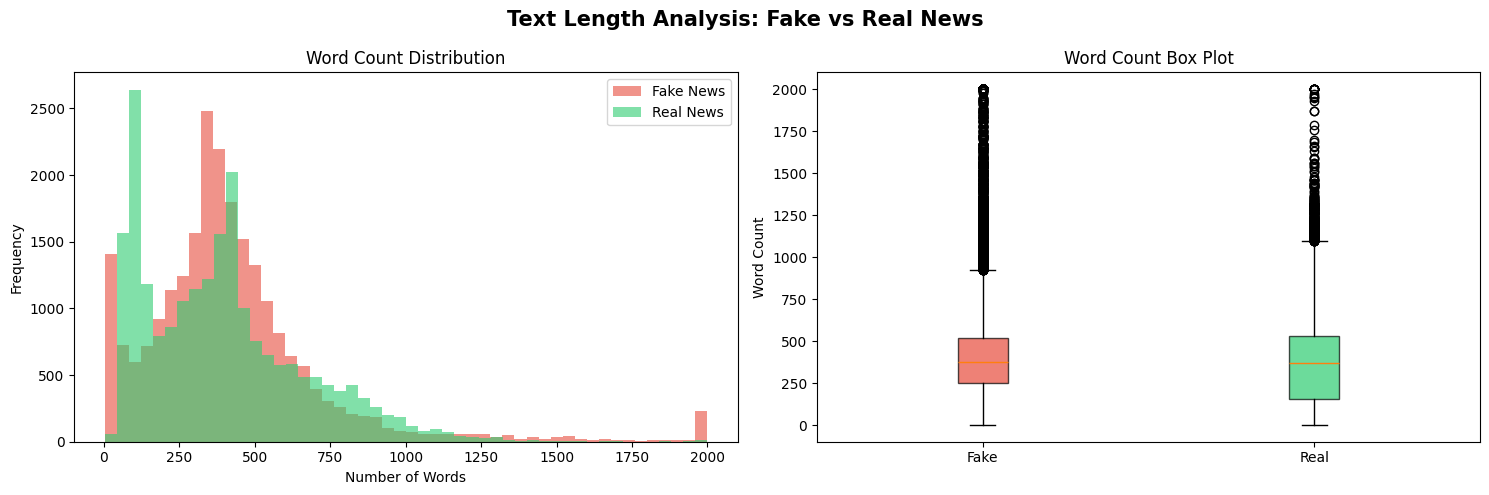

✅ Text length analysis plots saved.


In [11]:
# ============================================================
# SECTION 5C: TEXT LENGTH ANALYSIS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Text Length Analysis: Fake vs Real News', fontsize=15, fontweight='bold')

# --- Word Count Distribution ---
for label, color, name in [(0, '#E74C3C', 'Fake'), (1, '#2ECC71', 'Real')]:
    subset = df[df['label'] == label]['word_count']
    axes[0].hist(subset.clip(upper=2000), bins=50, alpha=0.6,
                 color=color, label=f'{name} News', edgecolor='none')
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# --- Box Plot: Word count per class ---
plot_data = [df[df['label'] == 0]['word_count'].clip(upper=2000),
             df[df['label'] == 1]['word_count'].clip(upper=2000)]
bp = axes[1].boxplot(plot_data,
                     labels=['Fake', 'Real'],
                     patch_artist=True,
                     notch=False)
for patch, color in zip(bp['boxes'], ['#E74C3C', '#2ECC71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Word Count Box Plot')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Text length analysis plots saved.")

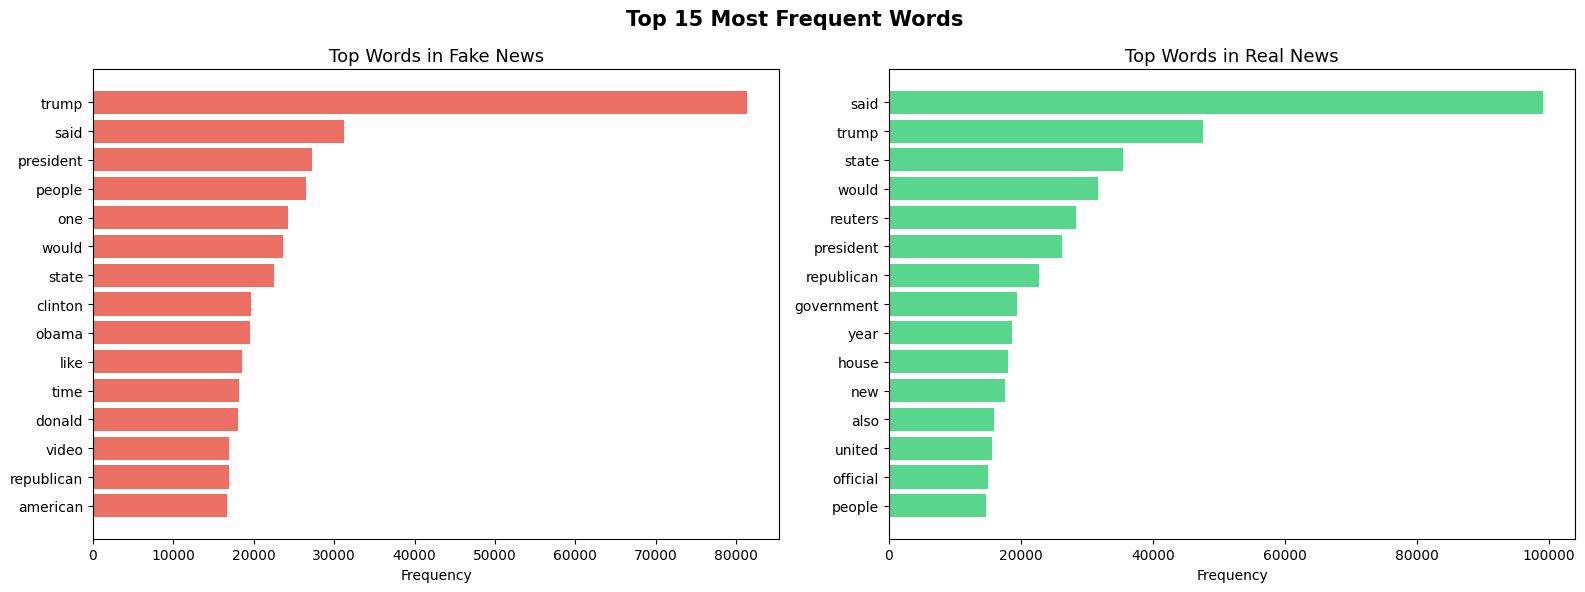

✅ Top words chart saved.


In [12]:
# ============================================================
# SECTION 5D: TOP 15 MOST FREQUENT WORDS PER CLASS
# ============================================================
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 15 Most Frequent Words', fontsize=15, fontweight='bold')

for idx, (label, title, color) in enumerate([
    (0, 'Fake News', '#E74C3C'),
    (1, 'Real News', '#2ECC71')
]):
    words = ' '.join(df[df['label'] == label]['clean_text']).split()
    most_common = Counter(words).most_common(15)
    words_list, counts = zip(*most_common)

    axes[idx].barh(list(words_list)[::-1], list(counts)[::-1],
                   color=color, alpha=0.8)
    axes[idx].set_title(f'Top Words in {title}', fontsize=13)
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Top words chart saved.")

In [13]:
# ============================================================
# SECTION 6: TF-IDF VECTORIZATION
# TF-IDF = Term Frequency × Inverse Document Frequency
# Converts text into numerical feature vectors
# ============================================================

# Drop rows with empty cleaned text
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

# Features (X) and Labels (y)
X = df['clean_text']
y = df['label']

# Split BEFORE vectorization to avoid data leakage
# 80% training, 20% testing
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training samples : {len(X_train_raw):,}")
print(f"Test samples     : {len(X_test_raw):,}")

# Initialize TF-IDF Vectorizer
# max_features=50000: keep top 50,000 unique words
# ngram_range=(1,2): use single words AND two-word phrases
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,           # Ignore terms appearing in fewer than 2 docs
    sublinear_tf=True   # Apply log(tf) to reduce impact of high-frequency terms
)

# Fit on training data ONLY, then transform both sets
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

print(f"\nTF-IDF training matrix shape: {X_train_tfidf.shape}")
print(f"TF-IDF test matrix shape    : {X_test_tfidf.shape}")
print(f"\nTotal vocabulary size: {len(tfidf.vocabulary_):,} unique tokens")
print("\n✅ TF-IDF vectorization complete!")

Training samples : 35,911
Test samples     : 8,978

TF-IDF training matrix shape: (35911, 50000)
TF-IDF test matrix shape    : (8978, 50000)

Total vocabulary size: 50,000 unique tokens

✅ TF-IDF vectorization complete!


In [14]:
y = df['label']

# Split BEFORE vectorization to avoid data leakage
# 80% training, 20% testing
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training samples : {len(X_train_raw):,}")
print(f"Test samples     : {len(X_test_raw):,}")

# Initialize TF-IDF Vectorizer
# max_features=50000: keep top 50,000 unique words
# ngram_range=(1,2): use single words AND two-word phrases
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,           # Ignore terms appearing in fewer than 2 docs
    sublinear_tf=True   # Apply log(tf) to reduce impact of high-frequency terms
)

# Fit on training data ONLY, then transform both sets
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

print(f"\nTF-IDF training matrix shape: {X_train_tfidf.shape}")
print(f"TF-IDF test matrix shape    : {X_test_tfidf.shape}")
print(f"\nTotal vocabulary size: {len(tfidf.vocabulary_):,} unique tokens")
print("\n✅ TF-IDF vectorization complete!")

Training samples : 35,911
Test samples     : 8,978

TF-IDF training matrix shape: (35911, 50000)
TF-IDF test matrix shape    : (8978, 50000)

Total vocabulary size: 50,000 unique tokens

✅ TF-IDF vectorization complete!


In [15]:
# ============================================================
# SECTION 7: TRADITIONAL ML MODEL TRAINING & EVALUATION
# Models: Logistic Regression + Multinomial Naive Bayes
# ============================================================

def evaluate_model(name, y_true, y_pred):
    """Calculate and display evaluation metrics for a model."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"  Model: {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred,
                                 target_names=['Fake (0)', 'Real (1)']))

    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1}

# Dictionary to store all results for later comparison
results = {}

# ----------------------------------------------------------
# MODEL 1: LOGISTIC REGRESSION
# A linear model that predicts probability of a class
# ----------------------------------------------------------
print("\n⏳ Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,          # Ensure convergence
    C=5.0,                  # Regularization strength (higher = less regularization)
    solver='lbfgs',
    random_state=SEED
)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)
results['Logistic Regression'] = evaluate_model('Logistic Regression', y_test, lr_pred)


⏳ Training Logistic Regression...

  Model: Logistic Regression
  Accuracy  : 0.9954  (99.54%)
  Precision : 0.9939
  Recall    : 0.9965
  F1-Score  : 0.9952

Detailed Classification Report:
              precision    recall  f1-score   support

    Fake (0)       1.00      0.99      1.00      4695
    Real (1)       0.99      1.00      1.00      4283

    accuracy                           1.00      8978
   macro avg       1.00      1.00      1.00      8978
weighted avg       1.00      1.00      1.00      8978



In [16]:
# ----------------------------------------------------------
# MODEL 2: MULTINOMIAL NAIVE BAYES
# Based on Bayes' theorem; great for text classification
# Works well with TF-IDF (non-negative values)
# ----------------------------------------------------------
print("⏳ Training Multinomial Naive Bayes...")
nb_model = MultinomialNB(alpha=0.1)   # alpha: Laplace smoothing
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)
results['Naive Bayes'] = evaluate_model('Multinomial Naive Bayes', y_test, nb_pred)

print("\n✅ Both ML models trained and evaluated!")

⏳ Training Multinomial Naive Bayes...

  Model: Multinomial Naive Bayes
  Accuracy  : 0.9686  (96.86%)
  Precision : 0.9640
  Recall    : 0.9703
  F1-Score  : 0.9672

Detailed Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.97      0.97      0.97      4695
    Real (1)       0.96      0.97      0.97      4283

    accuracy                           0.97      8978
   macro avg       0.97      0.97      0.97      8978
weighted avg       0.97      0.97      0.97      8978


✅ Both ML models trained and evaluated!


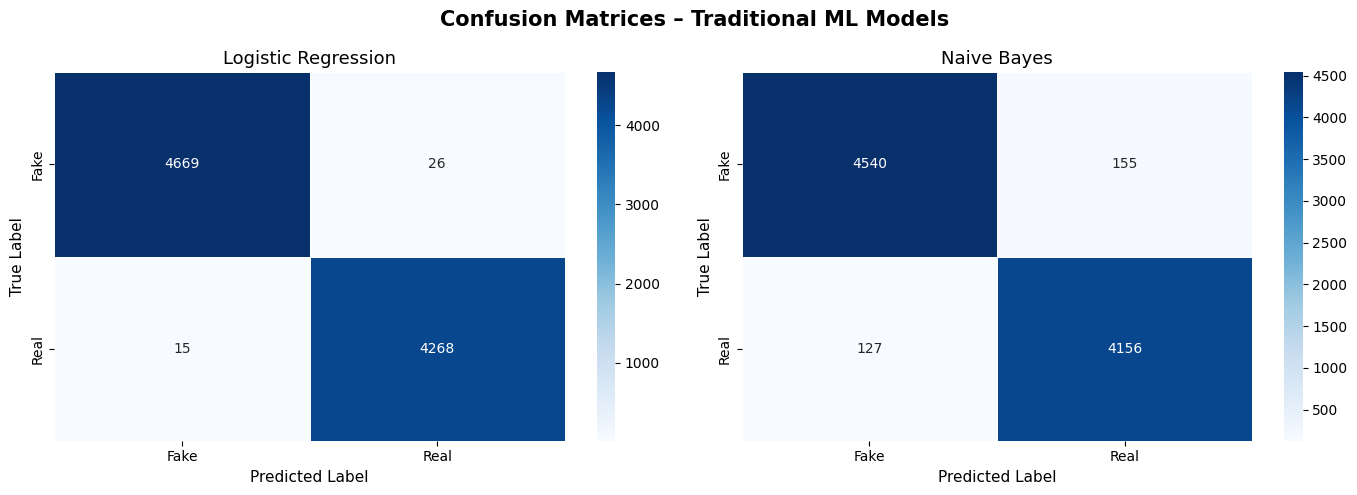

✅ Confusion matrices saved.


In [17]:
# ============================================================
# CONFUSION MATRICES FOR ML MODELS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices – Traditional ML Models', fontsize=15, fontweight='bold')

for ax, name, pred in [
    (axes[0], 'Logistic Regression', lr_pred),
    (axes[1], 'Naive Bayes', nb_pred)
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues',
        xticklabels=['Fake', 'Real'],
        yticklabels=['Fake', 'Real'],
        linewidths=0.5
    )
    ax.set_title(f'{name}', fontsize=13)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('ml_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved.")

In [18]:
# ============================================================
# SECTION 8A: PREPARE DATA FOR BERT
# BERT requires a specific input format:
#   [CLS] sentence tokens [SEP]
# We use HuggingFace's BertTokenizer for this.
# ============================================================

# Use a subset for faster training in Colab (resource-limited)
# Increase BERT_SAMPLES if you have more time/compute
BERT_SAMPLES = 8000   # 4000 fake + 4000 real
MAX_LEN = 128         # Max token length (256 captures more context but is slower)
BATCH_SIZE = 16       # Number of samples per gradient update
EPOCHS = 3            # Fine-tuning epochs (3 is standard for BERT)

# Sample balanced subset
bert_fake = df[df['label'] == 0].sample(BERT_SAMPLES // 2, random_state=SEED)
bert_real = df[df['label'] == 1].sample(BERT_SAMPLES // 2, random_state=SEED)
bert_df = pd.concat([bert_fake, bert_real]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"BERT dataset size: {len(bert_df):,} articles")
print(f"  Fake: {(bert_df['label']==0).sum():,}")
print(f"  Real: {(bert_df['label']==1).sum():,}")

# Use raw (not heavily cleaned) text for BERT — BERT handles its own tokenization
# We only do minimal cleaning (keep punctuation, capitalization matters less)
bert_texts = bert_df['content'].fillna('').tolist()
bert_labels = bert_df['label'].tolist()

# Split into train/test
from sklearn.model_selection import train_test_split as tts
train_texts, test_texts, train_labels, test_labels = tts(
    bert_texts, bert_labels, test_size=0.2, random_state=SEED, stratify=bert_labels
)

print(f"\nBERT Training samples: {len(train_texts):,}")
print(f"BERT Test samples    : {len(test_texts):,}")

# Load the BERT tokenizer from HuggingFace
print("\n⏳ Loading BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("✅ BERT tokenizer loaded!")

BERT dataset size: 8,000 articles
  Fake: 4,000
  Real: 4,000

BERT Training samples: 6,400
BERT Test samples    : 1,600

⏳ Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

✅ BERT tokenizer loaded!


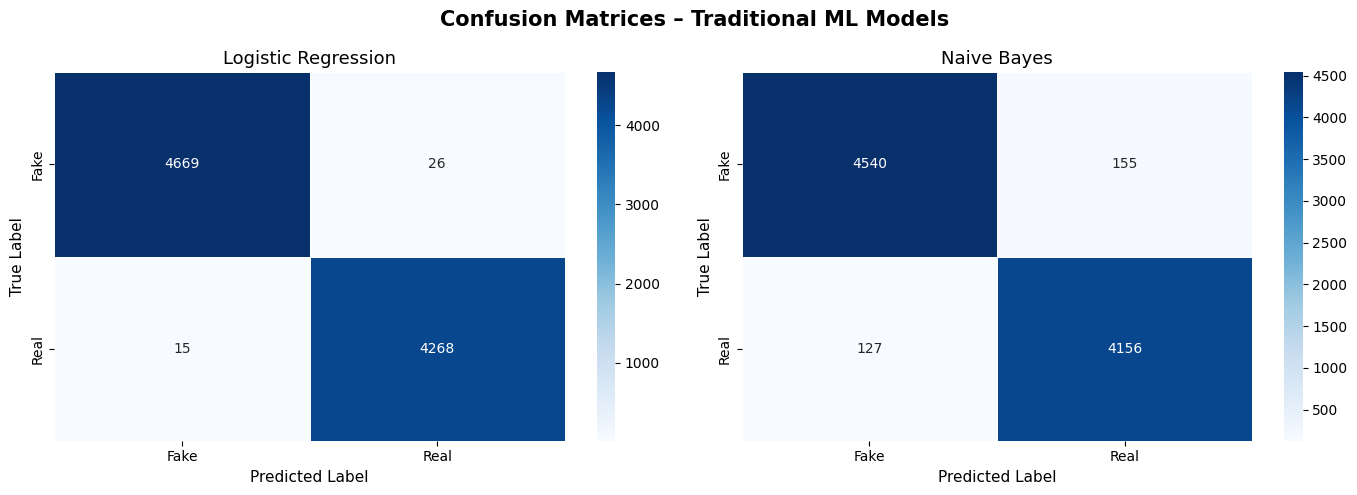

✅ Confusion matrices saved.


In [19]:
# ============================================================
# CONFUSION MATRICES FOR ML MODELS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices – Traditional ML Models', fontsize=15, fontweight='bold')

for ax, name, pred in [
    (axes[0], 'Logistic Regression', lr_pred),
    (axes[1], 'Naive Bayes', nb_pred)
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues',
        xticklabels=['Fake', 'Real'],
        yticklabels=['Fake', 'Real'],
        linewidths=0.5
    )
    ax.set_title(f'{name}', fontsize=13)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('ml_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved.")

In [20]:
# ============================================================
# SECTION 8B: CUSTOM PYTORCH DATASET CLASS
# ============================================================

class NewsDataset(Dataset):
    """
    Custom PyTorch Dataset for news articles.
    Tokenizes text using BERT tokenizer and prepares
    input_ids, attention_masks, and labels.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])[:512]  # BERT limit: 512 tokens

        # Tokenize: adds [CLS] and [SEP] tokens automatically
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',    # Pad shorter sequences
            truncation=True,         # Truncate longer sequences
            return_attention_mask=True,
            return_tensors='pt'      # Return PyTorch tensors
        )
        return {
            'input_ids'     : encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create Dataset objects
train_dataset = NewsDataset(train_texts, train_labels, tokenizer, MAX_LEN)
test_dataset  = NewsDataset(test_texts,  test_labels,  tokenizer, MAX_LEN)

# Create DataLoaders — efficient batch loading
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training batches : {len(train_loader)}")
print(f"Test batches     : {len(test_loader)}")
print("✅ DataLoaders ready!")

Training batches : 400
Test batches     : 100
✅ DataLoaders ready!


In [21]:
# ============================================================
# SECTION 8C: LOAD PRE-TRAINED BERT MODEL
# bert-base-uncased: 12 layers, 768 hidden units, 110M params
# We add a classification head on top for binary classification
# ============================================================

print("⏳ Loading BERT model for sequence classification...")

bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,           # Binary: Fake or Real
    output_attentions=False,
    output_hidden_states=False
)

# Move model to GPU if available
bert_model = bert_model.to(device)

# Count trainable parameters
total_params = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"✅ BERT model loaded and moved to {device}!")

⏳ Loading BERT model for sequence classification...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters    : 109,483,778
Trainable parameters: 109,483,778
✅ BERT model loaded and moved to cuda!


In [22]:
# ============================================================
# SECTION 8D: FINE-TUNE BERT
# We use AdamW optimizer with a learning rate scheduler
# (linear warmup + decay) — the standard BERT fine-tuning recipe
# ============================================================

# Optimizer: AdamW (Adam with weight decay fix — recommended for BERT)
optimizer = AdamW(
    bert_model.parameters(),
    lr=2e-5,            # Standard BERT fine-tuning LR: 2e-5 to 5e-5
    eps=1e-8            # Numerical stability
)

# Total training steps = batches per epoch × number of epochs
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)  # 10% warmup

# Learning rate scheduler: linear warmup then linear decay
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps}")

# Training loop
train_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    # ---- TRAINING PHASE ----
    bert_model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_num, batch in enumerate(train_loader):
        # Move batch to GPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Zero gradients from previous step
        optimizer.zero_grad()

        # Forward pass
        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # Backward pass
        loss.backward()

        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Print progress every 50 batches
        if (batch_num + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS} | Batch {batch_num+1}/{len(train_loader)} "
                  f"| Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(avg_loss)

    # ---- VALIDATION PHASE ----
    bert_model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():  # No gradient computation during eval
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_accuracies.append(val_acc)

    print(f"\n📊 Epoch {epoch+1}/{EPOCHS} Summary:")
    print(f"   Train Loss     : {avg_loss:.4f}")
    print(f"   Train Accuracy : {train_acc*100:.2f}%")
    print(f"   Val Accuracy   : {val_acc*100:.2f}%")
    print("-" * 45)

print("\n✅ BERT fine-tuning complete!")

Total training steps : 1200
Warmup steps         : 120
  Epoch 1/3 | Batch 50/400 | Loss: 0.4031
  Epoch 1/3 | Batch 100/400 | Loss: 0.0358
  Epoch 1/3 | Batch 150/400 | Loss: 0.0019
  Epoch 1/3 | Batch 200/400 | Loss: 0.0011
  Epoch 1/3 | Batch 250/400 | Loss: 0.0008
  Epoch 1/3 | Batch 300/400 | Loss: 0.0006
  Epoch 1/3 | Batch 350/400 | Loss: 0.0006
  Epoch 1/3 | Batch 400/400 | Loss: 0.0004

📊 Epoch 1/3 Summary:
   Train Loss     : 0.1051
   Train Accuracy : 95.56%
   Val Accuracy   : 99.50%
---------------------------------------------
  Epoch 2/3 | Batch 50/400 | Loss: 0.0002
  Epoch 2/3 | Batch 100/400 | Loss: 0.0002
  Epoch 2/3 | Batch 150/400 | Loss: 0.0002
  Epoch 2/3 | Batch 200/400 | Loss: 0.0002
  Epoch 2/3 | Batch 250/400 | Loss: 0.0001
  Epoch 2/3 | Batch 300/400 | Loss: 0.0001
  Epoch 2/3 | Batch 350/400 | Loss: 0.0001
  Epoch 2/3 | Batch 400/400 | Loss: 0.0001

📊 Epoch 2/3 Summary:
   Train Loss     : 0.0017
   Train Accuracy : 99.94%
   Val Accuracy   : 100.00%
------

In [23]:
# ============================================================
# SECTION 8E: EVALUATE BERT ON TEST SET
# ============================================================

bert_model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

# Store BERT results alongside ML results
results['BERT'] = evaluate_model('BERT (fine-tuned)', all_true, all_preds)


  Model: BERT (fine-tuned)
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

Detailed Classification Report:
              precision    recall  f1-score   support

    Fake (0)       1.00      1.00      1.00       800
    Real (1)       1.00      1.00      1.00       800

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



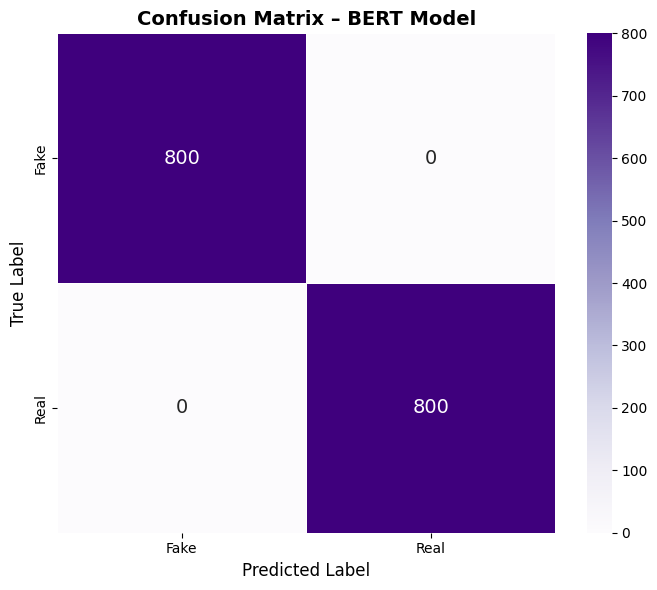

✅ BERT confusion matrix saved.


In [24]:
# ============================================================
# BERT CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))
cm_bert = confusion_matrix(all_true, all_preds)
sns.heatmap(
    cm_bert, annot=True, fmt='d', ax=ax,
    cmap='Purples',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real'],
    linewidths=0.5,
    annot_kws={'size': 14}
)
ax.set_title('Confusion Matrix – BERT Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ BERT confusion matrix saved.")

In [25]:
# ============================================================
# SECTION 9: COMPREHENSIVE MODEL COMPARISON
# ============================================================

# Build a summary DataFrame from all results
comparison_df = pd.DataFrame(list(results.values()))
comparison_df = comparison_df.set_index('Model')

print("\n" + "=" * 65)
print("          FINAL MODEL COMPARISON SUMMARY")
print("=" * 65)
print(comparison_df.round(4).to_string())
print("=" * 65)

best_model = comparison_df['F1-Score'].idxmax()
print(f"\n🏆 Best model by F1-Score: {best_model}")


          FINAL MODEL COMPARISON SUMMARY
                         Accuracy  Precision  Recall  F1-Score
Model                                                         
Logistic Regression        0.9954     0.9939  0.9965    0.9952
Multinomial Naive Bayes    0.9686     0.9640  0.9703    0.9672
BERT (fine-tuned)          1.0000     1.0000  1.0000    1.0000

🏆 Best model by F1-Score: BERT (fine-tuned)


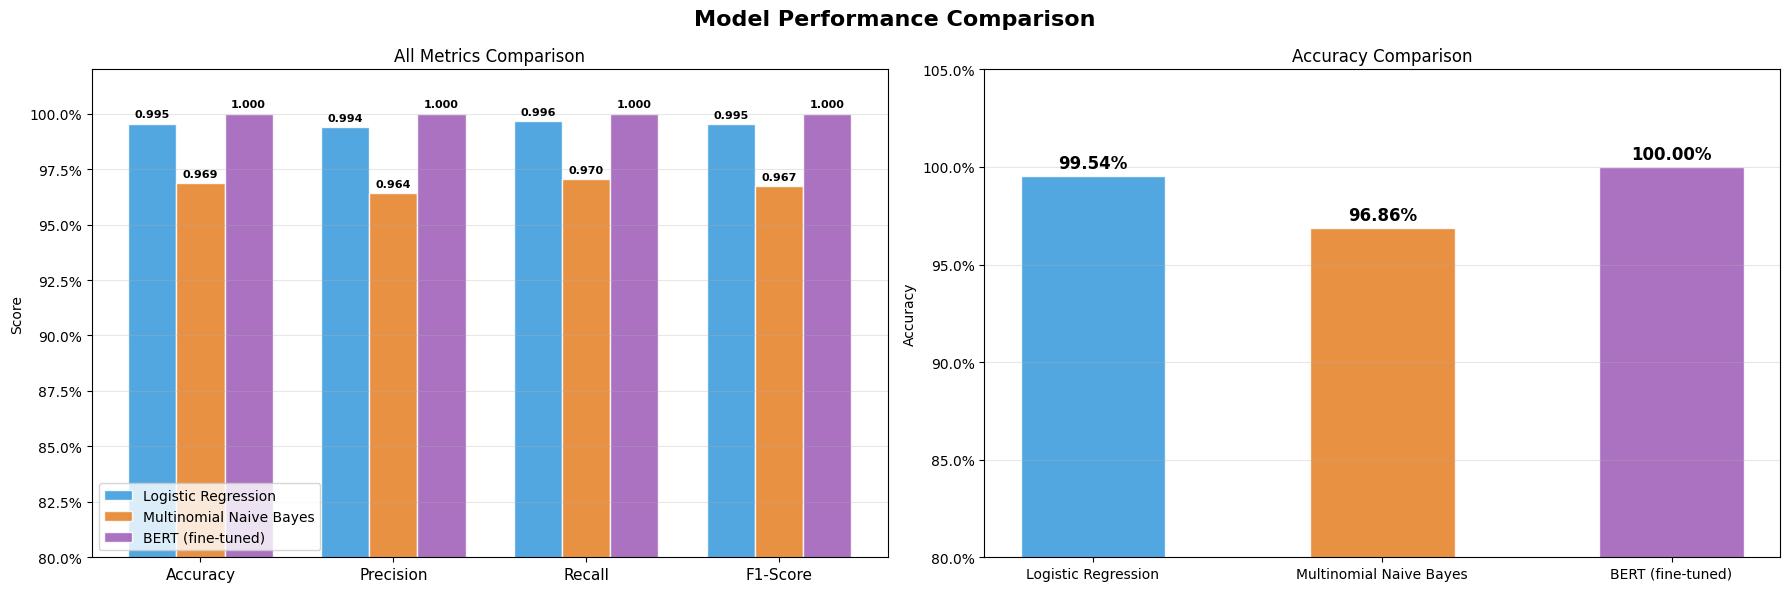

✅ Model comparison chart saved.


In [26]:
# ============================================================
# GROUPED BAR CHART: All Models × All Metrics
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = comparison_df.index.tolist()
x = np.arange(len(metrics))
width = 0.25
palette = ['#3498DB', '#E67E22', '#9B59B6']   # Blue, Orange, Purple

# --- Grouped Bar Chart ---
for i, (model, color) in enumerate(zip(model_names, palette)):
    vals = [comparison_df.loc[model, m] for m in metrics]
    offset = (i - len(model_names)/2 + 0.5) * width
    bars = axes[0].bar(x + offset, vals, width, label=model,
                       color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.002,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=11)
axes[0].set_ylim(0.8, 1.02)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics Comparison')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].grid(axis='y', alpha=0.3)

# --- Accuracy Comparison Bar Chart ---
accs = [comparison_df.loc[m, 'Accuracy'] for m in model_names]
bars2 = axes[1].bar(model_names, accs, color=palette, alpha=0.85,
                    edgecolor='white', width=0.5)
for bar, v in zip(bars2, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{v*100:.2f}%', ha='center', va='bottom',
                 fontsize=12, fontweight='bold')
axes[1].set_ylim(0.8, 1.05)
axes[1].set_title('Accuracy Comparison')
axes[1].set_ylabel('Accuracy')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison chart saved.")

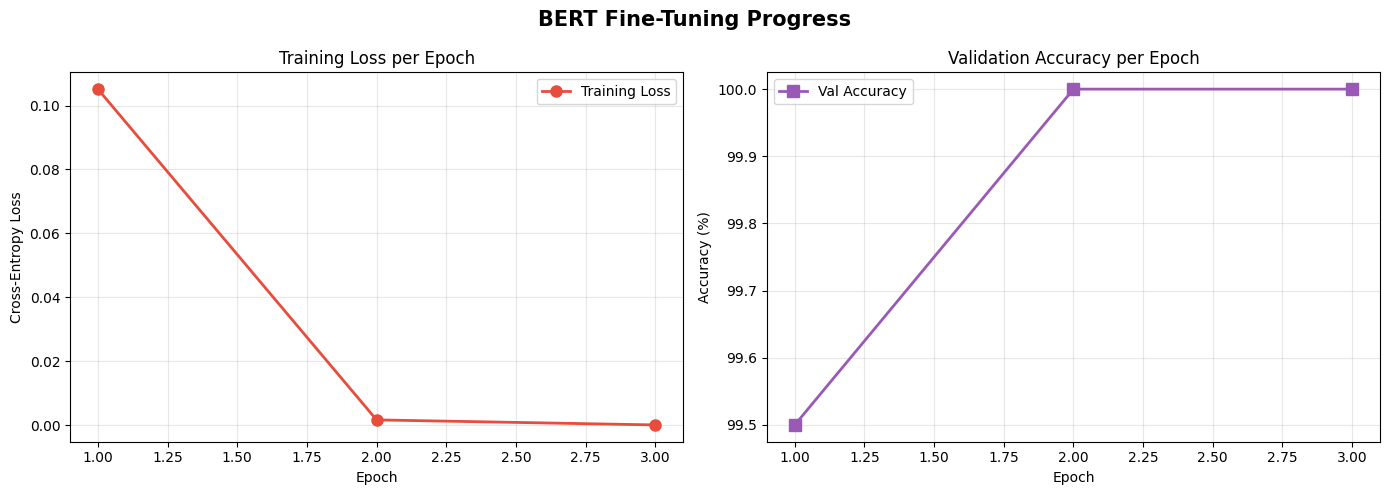

✅ BERT training curves saved.


In [27]:
# ============================================================
# BERT TRAINING LOSS AND ACCURACY CURVES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BERT Fine-Tuning Progress', fontsize=15, fontweight='bold')

epochs_range = range(1, EPOCHS + 1)

# Training Loss
axes[0].plot(epochs_range, train_losses, 'o-', color='#E74C3C',
             linewidth=2, markersize=8, label='Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss per Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Validation Accuracy
axes[1].plot(epochs_range, [v*100 for v in val_accuracies], 's-',
             color='#9B59B6', linewidth=2, markersize=8, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Validation Accuracy per Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ BERT training curves saved.")

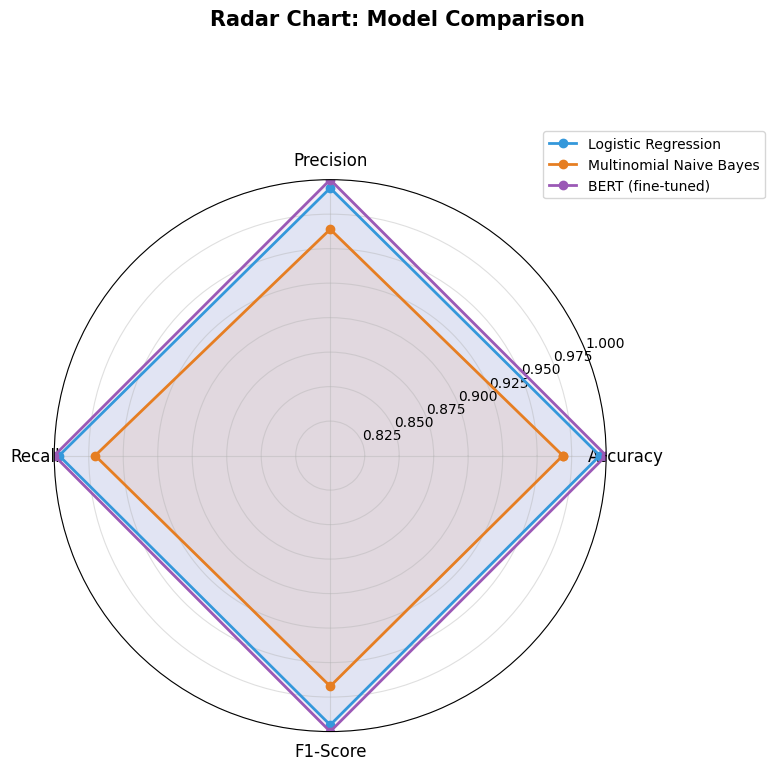

✅ Radar chart saved.


In [28]:
# ============================================================
# RADAR CHART: Multi-dimensional model comparison
# ============================================================

import matplotlib.patches as mpatches

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Radar Chart: Model Comparison', fontsize=15, fontweight='bold', y=1.02)

colors_radar = ['#3498DB', '#E67E22', '#9B59B6']

for model, color in zip(model_names, colors_radar):
    values = [comparison_df.loc[model, c] for c in categories]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0.8, 1.0)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Radar chart saved.")

In [32]:
# ============================================================
# SECTION 10: PREDICT ON CUSTOM NEWS TEXT
# Test both ML models and BERT on new inputs
# ============================================================

def predict_news(text, model_choice='all'):
    """
    Predict whether a news article is Fake or Real.
    model_choice: 'lr', 'nb', 'bert', or 'all'
    """
    print(f"\n📰 Input text: '{text[:100]}...'\n")

    # --- ML Models ---
    clean = preprocess_text(text)
    vec = tfidf.transform([clean])

    if model_choice in ('lr', 'all'):
        lr_result = lr_model.predict(vec)[0]
        lr_proba = lr_model.predict_proba(vec)[0]
        label = '✅ REAL' if lr_result == 1 else '❌ FAKE'
        print(f"  Logistic Regression : {label} "
              f"(Fake: {lr_proba[0]:.2%}, Real: {lr_proba[1]:.2%})")

    if model_choice in ('nb', 'all'):
        nb_result = nb_model.predict(vec)[0]
        nb_proba = nb_model.predict_proba(vec)[0]
        label = '✅ REAL' if nb_result == 1 else '❌ FAKE'
        print(f"  Naive Bayes         : {label} "
              f"(Fake: {nb_proba[0]:.2%}, Real: {nb_proba[1]:.2%})")

    # --- BERT Model ---
    if model_choice in ('bert', 'all'):
        bert_model.eval()
        encoding = tokenizer(
            text[:512],
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
            prediction = np.argmax(probs)

        label = '✅ REAL' if prediction == 1 else '❌ FAKE'
        print(f"  BERT                : {label} "
              f"(Fake: {probs[0]:.2%}, Real: {probs[1]:.2%})")

# --- Test Examples ---
fake_example = """
SHOCKING: Scientists confirm that 5G towers are spreading COVID-19 virus
and the government is hiding the truth. Thousands of towers were secretly
installed while people were in lockdown. Share this before it's deleted!
"""

real_example = """
The Federal Reserve announced a 0.25 percentage point interest rate increase
on Wednesday, the tenth consecutive hike since March 2022, as the central
bank continues to battle elevated inflation that remains above its 2% target.
"""

print("=" * 60)
print("TEST 1: Likely FAKE News")
predict_news(fake_example)

print("\n" + "=" * 60)
print("TEST 2: Likely REAL News")
predict_news(real_example)

TEST 1: Likely FAKE News

📰 Input text: '
SHOCKING: Scientists confirm that 5G towers are spreading COVID-19 virus
and the government is hidi...'

  Logistic Regression : ❌ FAKE (Fake: 89.17%, Real: 10.83%)
  Naive Bayes         : ❌ FAKE (Fake: 95.14%, Real: 4.86%)
  BERT                : ❌ FAKE (Fake: 99.99%, Real: 0.01%)

TEST 2: Likely REAL News

📰 Input text: '
The Federal Reserve announced a 0.25 percentage point interest rate increase
on Wednesday, the tent...'

  Logistic Regression : ✅ REAL (Fake: 40.27%, Real: 59.73%)
  Naive Bayes         : ✅ REAL (Fake: 3.66%, Real: 96.34%)
  BERT                : ❌ FAKE (Fake: 99.95%, Real: 0.05%)
